# 🚗 RTA Dataset — Analyse Exploratoire des Données (EDA)
## Notebook 01 — Final

---

| Champ | Valeur |
|-------|--------|
| **Auteur** | [Votre Nom] |
| **Module** | Machine Learning — M. Abdallah Khemais |
| **Dataset** | RTA Dataset (Road Traffic Accidents) |
| **Tache** | Classification multiclasse — `Accident_severity` |

---

## Plan
1. Imports
2. Chargement — shuffle sur 12 300 lignes — echantillon 3 000
3. Inspection generale
4. Valeurs manquantes (sans suppression)
5. Distribution de la variable cible + desequilibre
6. Distributions des variables
7. Analyse bivariee
8. Correlations
9. Outliers
10. Sauvegarde

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42

print('Imports OK')

Imports OK


## 2. Chargement des Donnees

**Strategie :**
- On charge le dataset **complet** (12 300 lignes)
- On **shuffle toutes les lignes** (`random_state=42`) avant tout traitement
- On prend les **3 000 premieres lignes** apres shuffle comme echantillon de travail

Pourquoi shuffler sur tout le dataset avant d'echantillonner ?  
Si les donnees sont triees par date, gravite ou zone geographique, un echantillon des 3000 premieres lignes non shufflees serait biaise. Le shuffle garantit un echantillon representatif de l'ensemble.

In [4]:
# --- Chargement complet ---
df_full = pd.read_csv('../Data/RTA Dataset.csv')
print(f'Dataset complet  : {df_full.shape[0]} lignes x {df_full.shape[1]} colonnes')

# --- Shuffle sur TOUTES les lignes (12 300) ---
df_full = df_full.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f'Shuffle effectue sur {df_full.shape[0]} lignes (random_state={RANDOM_STATE})')

# --- Echantillon 3 000 lignes ---
df = df_full.head(3000).copy()
print(f'Echantillon retenu : {df.shape[0]} lignes x {df.shape[1]} colonnes')

TARGET = 'Accident_severity'
df.head()

Dataset complet  : 12316 lignes x 32 colonnes
Shuffle effectue sur 12316 lignes (random_state=42)
Echantillon retenu : 3000 lignes x 32 colonnes


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,14:27:00,Friday,Over 51,Male,Junior high school,Employee,Above 10yr,NaN,Owner,2-5yrs,...,U-Turn,na,na,na,na,Driver,Normal,Not a Pedestrian,Changing lane to the left,Slight Injury
1,16:00:00,Sunday,Under 18,Male,Junior high school,Employee,Below 1yr,Automobile,Owner,NaN,...,Other,na,na,na,na,NaN,NaN,Not a Pedestrian,Driving carelessly,Slight Injury
2,16:56:00,Wednesday,18-30,Male,NaN,NaN,NaN,NaN,NaN,NaN,...,Getting off,Driver or rider,Male,18-30,3,Driver,Normal,Not a Pedestrian,No distancing,Serious Injury
3,15:48:00,Tuesday,31-50,Male,Junior high school,Employee,Below 1yr,Public (12 seats),Owner,NaN,...,Going straight,Driver or rider,Male,18-30,3,Self-employed,Normal,Not a Pedestrian,Moving Backward,Slight Injury
4,12:48:00,Friday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,Unknown,...,Going straight,Passenger,Female,31-50,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury


## 3. Inspection Generale

In [5]:
print(f'Dimensions : {df.shape}')
print(f'Memoire    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB\n')
df.info()

Dimensions : (3000, 32)
Memoire    : 5193.9 KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         3000 non-null   object
 1   Day_of_week                  3000 non-null   object
 2   Age_band_of_driver           3000 non-null   object
 3   Sex_of_driver                3000 non-null   object
 4   Educational_level            2820 non-null   object
 5   Vehicle_driver_relation      2857 non-null   object
 6   Driving_experience           2788 non-null   object
 7   Type_of_vehicle              2763 non-null   object
 8   Owner_of_vehicle             2888 non-null   object
 9   Service_year_of_vehicle      2038 non-null   object
 10  Defect_of_vehicle            1961 non-null   object
 11  Area_accident_occured        2944 non-null   object
 12  Lanes_or_Medians             2904 non-null

In [6]:
# Identification des types
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables numeriques   ({len(num_cols)}) : {num_cols}')
print(f'Variables categorielles ({len(cat_cols)}) : {cat_cols}')

Variables numeriques   (2) : ['Number_of_vehicles_involved', 'Number_of_casualties']
Variables categorielles (30) : ['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


In [7]:
print('=== Statistiques — Variables numeriques ===')
df[num_cols].describe().T.style.background_gradient(cmap='Blues')

=== Statistiques — Variables numeriques ===


,count,mean,std,min,25%,50%,75%,max
Number_of_vehicles_involved,3000.000000,2.034667,0.682852,1.000000,2.000000,2.000000,2.000000,7.000000
Number_of_casualties,3000.000000,1.576000,1.054796,1.000000,1.000000,1.000000,2.000000,8.000000


In [8]:
print('=== Statistiques — Variables categorielles ===')
df[cat_cols].describe().T

=== Statistiques — Variables categorielles ===


,count,unique,top,freq
Time,3000,783,17:10:00,29
Day_of_week,3000,7,Friday,506
Age_band_of_driver,3000,5,18-30,1058
Sex_of_driver,3000,3,Male,2784
Educational_level,2820,7,Junior high school,1855
Vehicle_driver_relation,2857,4,Employee,2350
Driving_experience,2788,7,5-10yr,783
Type_of_vehicle,2763,17,Automobile,787
Owner_of_vehicle,2888,4,Owner,2538
Service_year_of_vehicle,2038,6,Unknown,718


## 4. Valeurs Manquantes

> **Choix methodologique : on ne supprime aucune ligne.**
>
> Supprimer une ligne a cause d'une valeur manquante dans une colonne revient a jeter toute l'information contenue dans les autres colonnes de cette ligne.
> Ces valeurs seront **imputees dans le pipeline sklearn** du notebook de modelisation :
> - **Mediane** pour les variables numeriques (robuste aux outliers)
> - **Mode (most_frequent)** pour les variables categorielles

16 colonnes avec valeurs manquantes :
                         Count  Pct (%)
Defect_of_vehicle         1039    34.63
Service_year_of_vehicle    962    32.07
Work_of_casuality          788    26.27
Fitness_of_casuality       643    21.43
Type_of_vehicle            237     7.90
Types_of_Junction          221     7.37
Driving_experience         212     7.07
Educational_level          180     6.00
Vehicle_driver_relation    143     4.77
Owner_of_vehicle           112     3.73
Lanes_or_Medians            96     3.20
Vehicle_movement            88     2.93
Area_accident_occured       56     1.87
Road_surface_type           50     1.67
Type_of_collision           35     1.17
Road_allignment             31     1.03


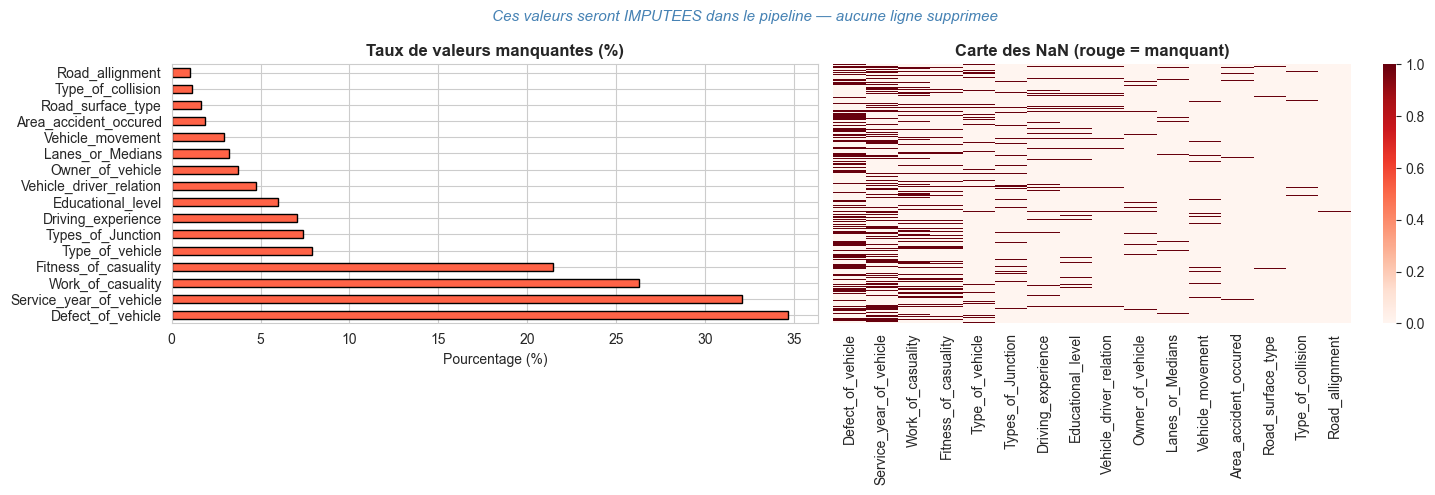

In [9]:
missing = pd.DataFrame({
    'Count': df.isnull().sum(),
    'Pct (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pct (%)', ascending=False)

missing_cols = missing[missing['Count'] > 0]

if len(missing_cols) == 0:
    print('Aucune valeur manquante detectee.')
else:
    print(f'{len(missing_cols)} colonnes avec valeurs manquantes :')
    print(missing_cols.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    missing_cols['Pct (%)'].plot(
        kind='barh', ax=axes[0], color='tomato', edgecolor='black'
    )
    axes[0].set_title('Taux de valeurs manquantes (%)', fontweight='bold')
    axes[0].set_xlabel('Pourcentage (%)')

    sns.heatmap(
        df[missing_cols.index].isnull().astype(int),
        ax=axes[1], cmap='Reds', cbar=True,
        yticklabels=False
    )
    axes[1].set_title('Carte des NaN (rouge = manquant)', fontweight='bold')

    plt.suptitle(
        'Ces valeurs seront IMPUTEES dans le pipeline — aucune ligne supprimee',
        color='steelblue', style='italic', fontsize=11
    )
    plt.tight_layout()
    plt.show()

## 5. Distribution de la Variable Cible & Desequilibre

On utilise plusieurs metriques ici car l'**accuracy seule est insuffisante** sur un dataset desequilibre.  
Un modele naive qui predit toujours 'Slight Injury' aurait ~72% d'accuracy sans rien apprendre.

=== Distribution de la variable cible ===
  Slight Injury                  |||||||||||||||||||||||||||||||||||||||||  2510 (83.7%)
  Serious Injury                 |||||||   445 (14.8%)
  Fatal injury                       45 (1.5%)

  => Ratio desequilibre (max/min) : 55.8x
  => Accuracy d'un modele naif (toujours Slight) : 83.7%
  => C'est pourquoi on utilisera F1-macro, Precision, Recall, AUC en plus de l'Accuracy


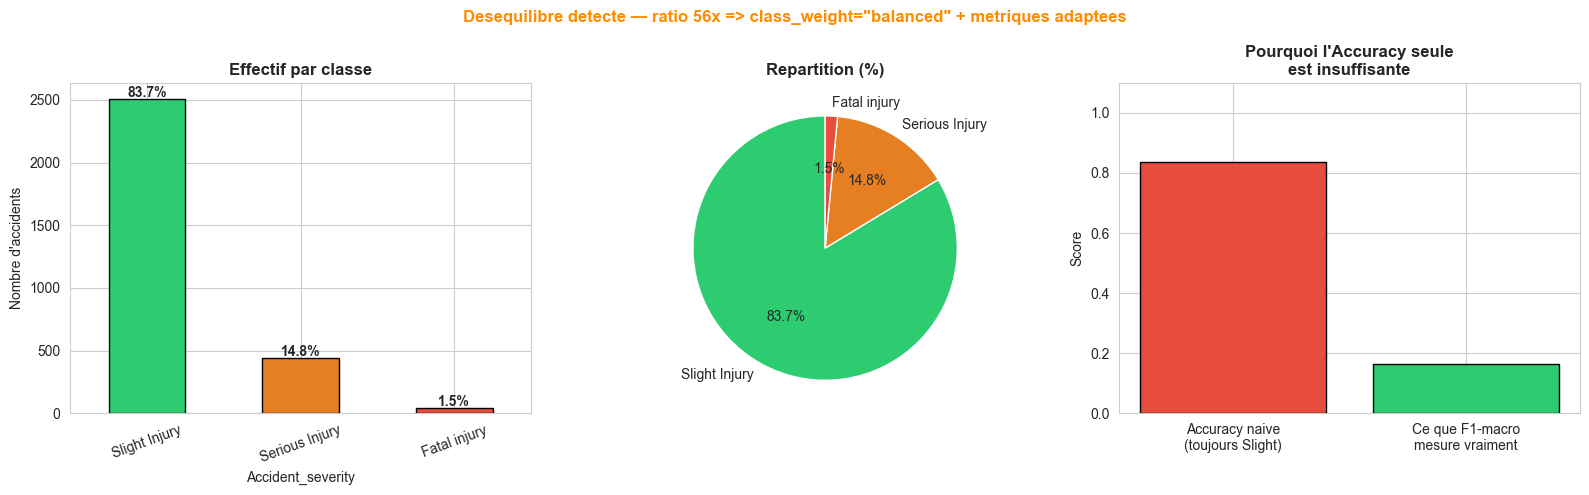

In [10]:
counts = df[TARGET].value_counts()
pcts   = df[TARGET].value_counts(normalize=True) * 100

print('=== Distribution de la variable cible ===')
for cls in counts.index:
    bar = '|' * int(pcts[cls] / 2)
    print(f'  {cls:<30} {bar} {counts[cls]:>5} ({pcts[cls]:.1f}%)')

ratio = counts.max() / counts.min()
print(f'\n  => Ratio desequilibre (max/min) : {ratio:.1f}x')
print(f'  => Accuracy d\'un modele naif (toujours Slight) : {pcts.max():.1f}%')
print('  => C\'est pourquoi on utilisera F1-macro, Precision, Recall, AUC en plus de l\'Accuracy')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Barplot
colors = ['#2ECC71','#E67E22','#E74C3C']
counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Effectif par classe', fontweight='bold')
axes[0].set_ylabel('Nombre d\'accidents')
axes[0].tick_params(axis='x', rotation=20)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 10, f'{p:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Repartition (%)', fontweight='bold')

# Baseline naif vs F1-macro attendu
axes[2].bar(
    ['Accuracy naive\n(toujours Slight)', 'Ce que F1-macro\nmesure vraiment'],
    [pcts.max() / 100, 1 - pcts.max() / 100],
    color=['#E74C3C','#2ECC71'], edgecolor='black'
)
axes[2].set_title('Pourquoi l\'Accuracy seule\nest insuffisante', fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1.1)

plt.suptitle(
    f'Desequilibre detecte — ratio {ratio:.0f}x => class_weight="balanced" + metriques adaptees',
    fontsize=12, fontweight='bold', color='darkorange'
)
plt.tight_layout()
plt.show()

## 6. Distributions des Variables

### 6.1 Variables numeriques

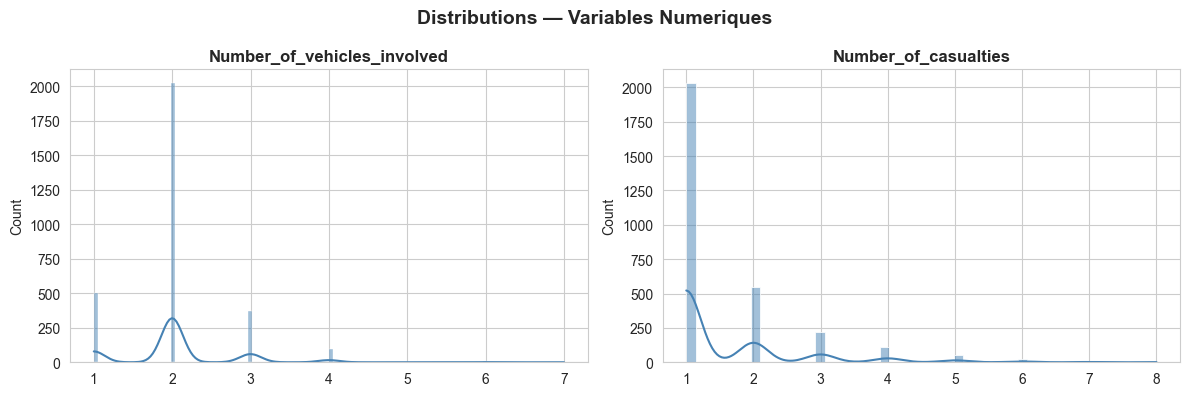

In [11]:
if len(num_cols) > 0:
    n_cols = min(3, len(num_cols))
    n_rows = (len(num_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_cols):
        sns.histplot(df[col].dropna(), ax=axes[i], kde=True,
                     color='steelblue', edgecolor='white')
        axes[i].set_title(f'{col}', fontweight='bold')
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distributions — Variables Numeriques', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Pas de variables numeriques.')

### 6.2 Variables categorielles (top 9)

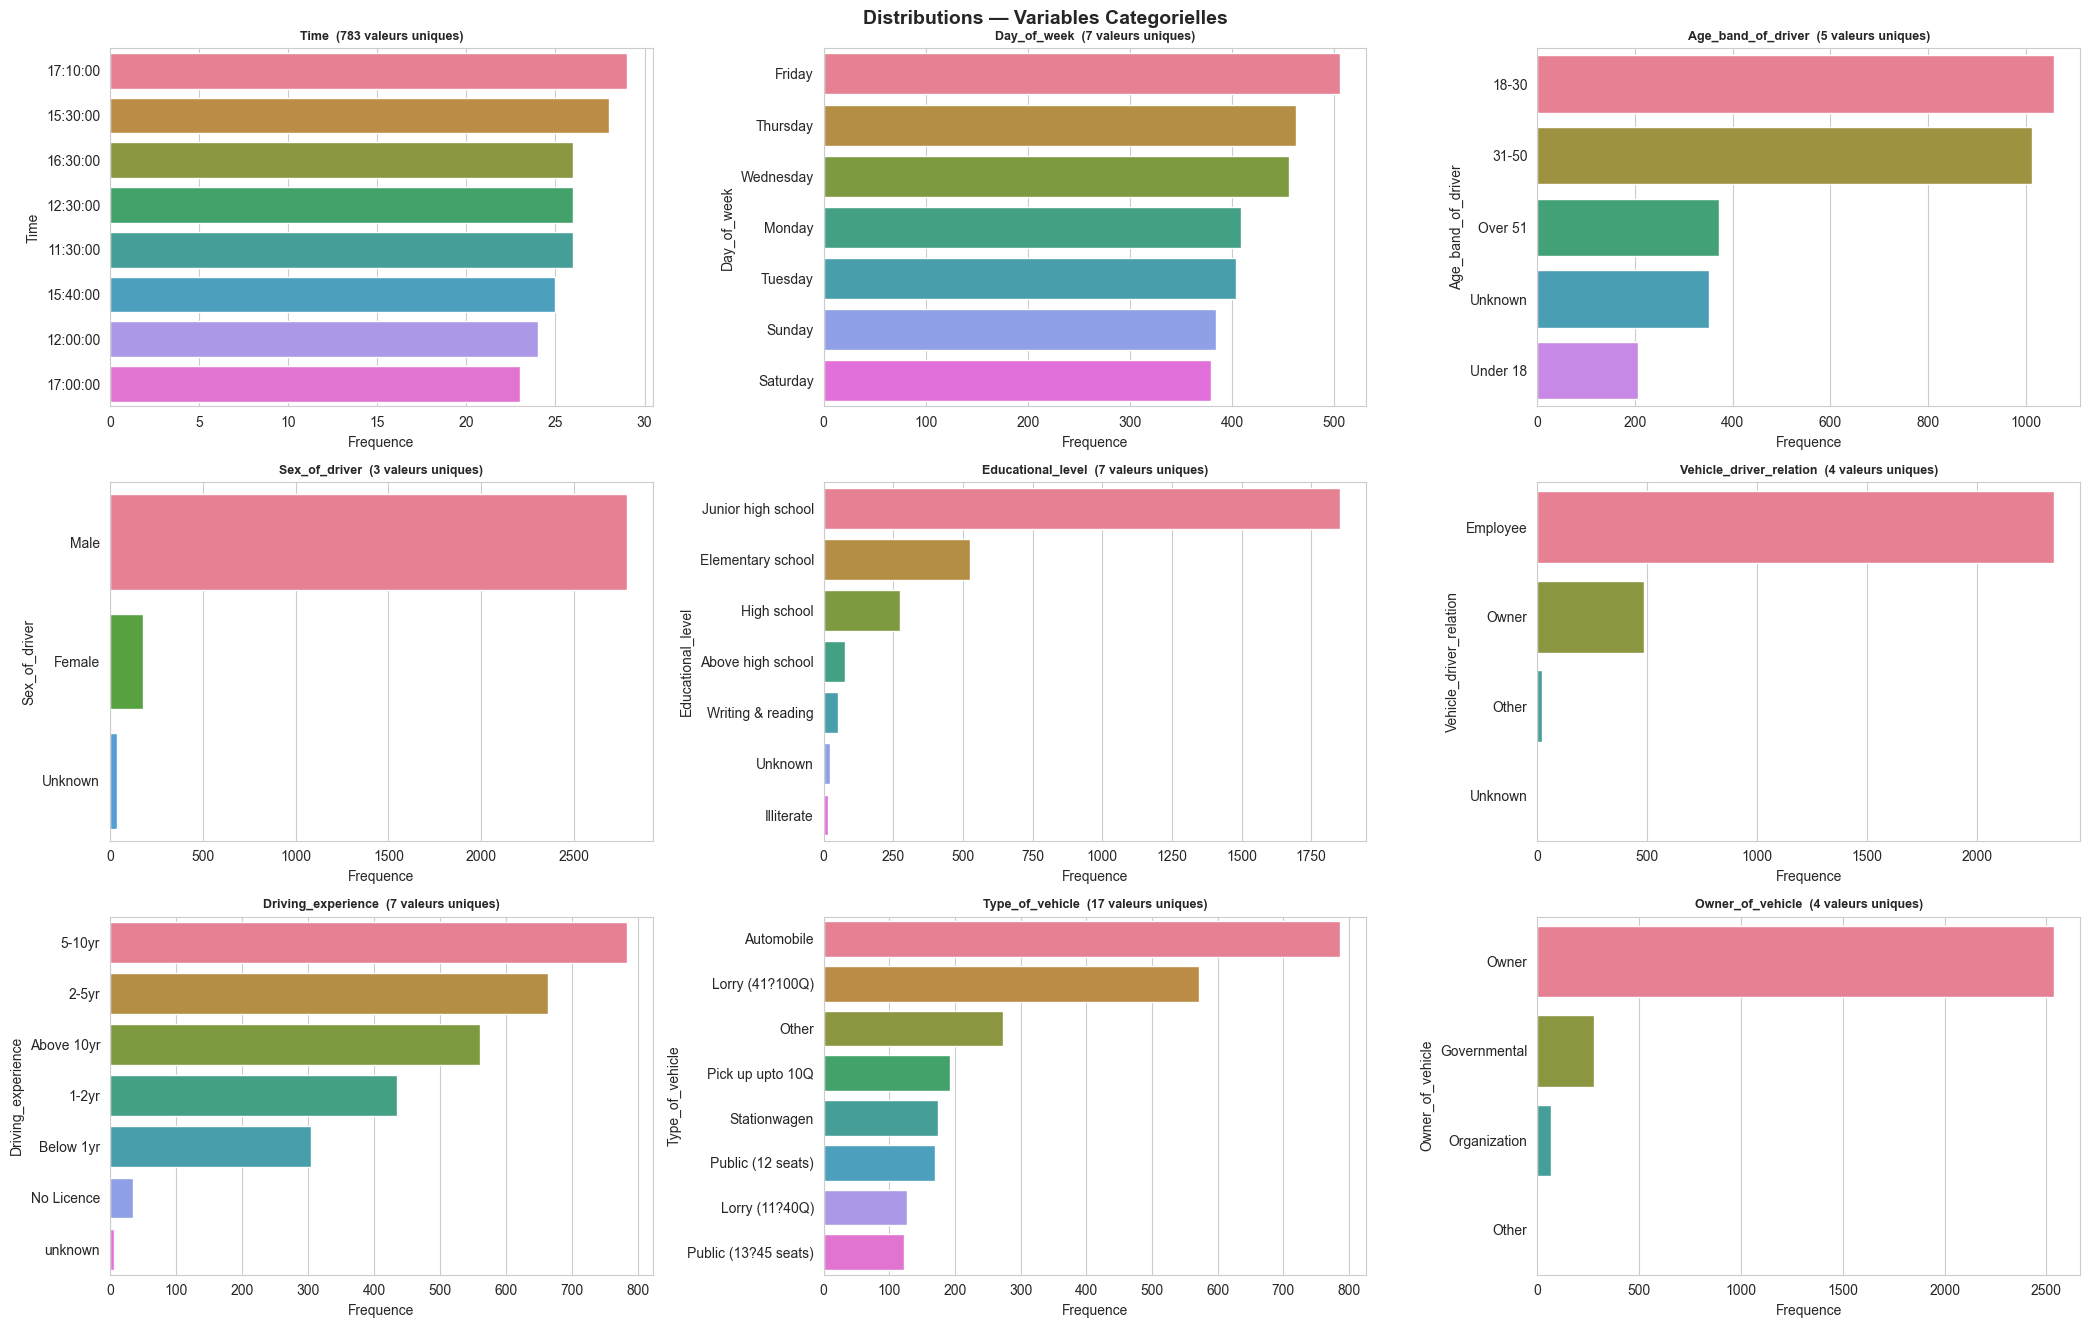

In [12]:
cat_to_plot = [c for c in cat_cols if c != TARGET][:9]
n_c = 3
n_r = (len(cat_to_plot) + n_c - 1) // n_c

fig, axes = plt.subplots(n_r, n_c, figsize=(7 * n_c, 4.5 * n_r))
axes = np.array(axes).flatten()

for i, col in enumerate(cat_to_plot):
    top = df[col].value_counts().head(8)
    sns.barplot(x=top.values, y=top.index, ax=axes[i],
                palette='husl', orient='h')
    axes[i].set_title(f'{col}  ({df[col].nunique()} valeurs uniques)', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Frequence')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions — Variables Categorielles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Analyse Bivariee — Variables vs Cible

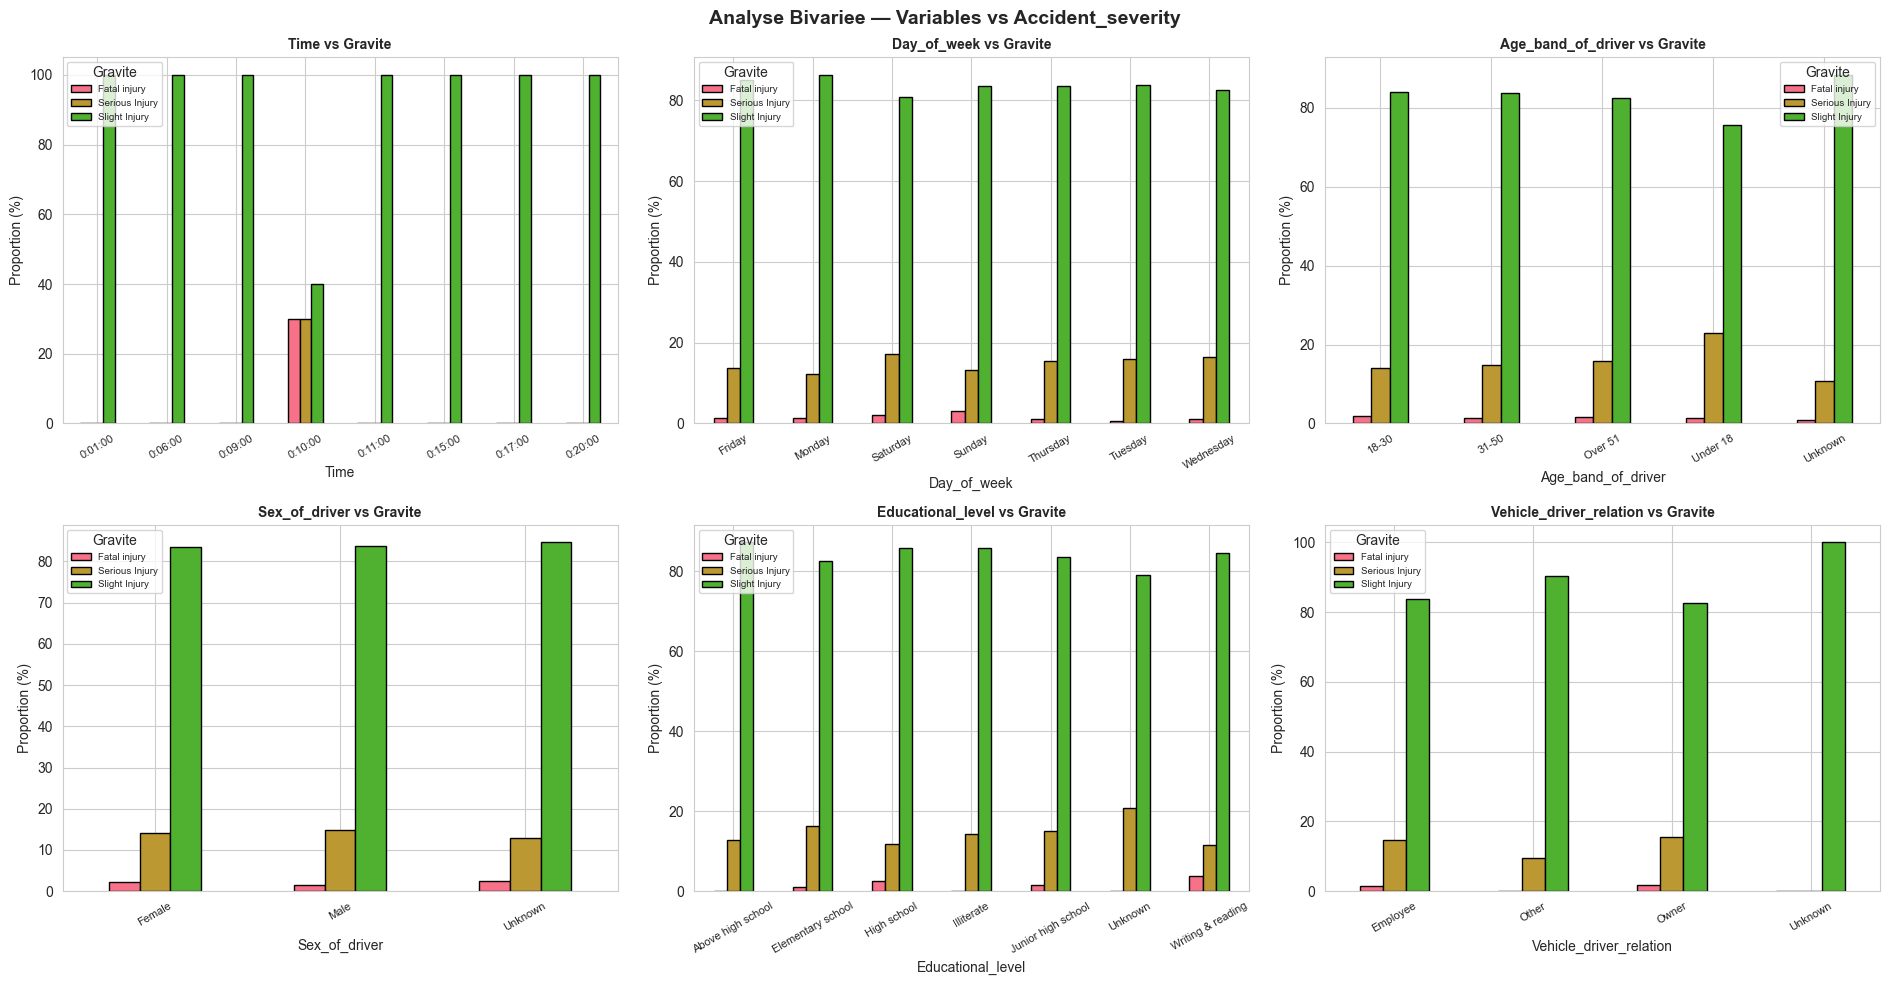

In [13]:
key_feats = [c for c in cat_cols if c != TARGET][:6]
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
axes = axes.flatten()

for i, feat in enumerate(key_feats):
    ct = pd.crosstab(df[feat], df[TARGET], normalize='index') * 100
    ct.head(8).plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{feat} vs Gravite', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Proportion (%)')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].legend(fontsize=7, title='Gravite')

plt.suptitle('Analyse Bivariee — Variables vs Accident_severity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Matrice de Correlation (Variables Numeriques)

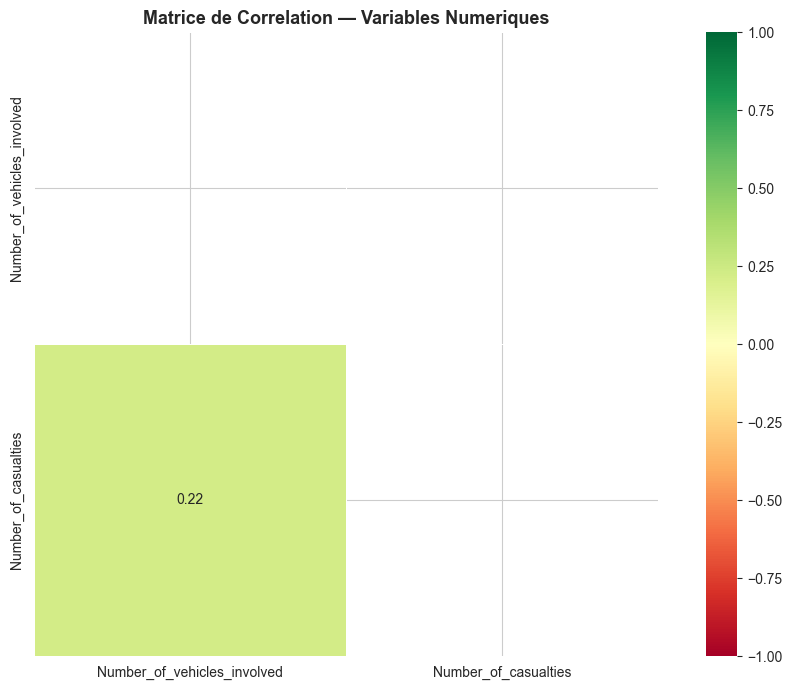

In [14]:
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f',
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        linewidths=0.5, square=True
    )
    plt.title('Matrice de Correlation — Variables Numeriques',
              fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Pas assez de variables numeriques pour la matrice de correlation.')

## 9. Detection des Outliers (Variables Numeriques)

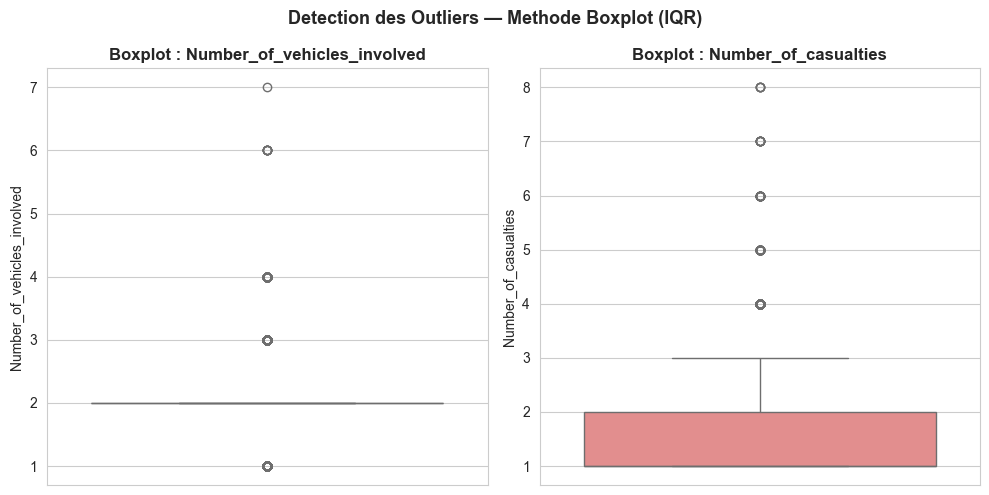


Quantification des outliers (methode IQR) :
  Number_of_vehicles_involved         : 979 outliers (32.6%)
  Number_of_casualties                : 199 outliers (6.6%)


In [15]:
if len(num_cols) > 0:
    fig, axes = plt.subplots(1, len(num_cols),
                             figsize=(5 * len(num_cols), 5))
    if len(num_cols) == 1:
        axes = [axes]

    for i, col in enumerate(num_cols):
        sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
        axes[i].set_title(f'Boxplot : {col}', fontweight='bold')

    plt.suptitle('Detection des Outliers — Methode Boxplot (IQR)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\nQuantification des outliers (methode IQR) :')
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
        print(f'  {col:<35} : {n_out} outliers ({n_out/len(df)*100:.1f}%)')

## 10. Sauvegarde & Synthese

### Synthese de l'EDA

| Aspect | Observation |
|--------|-------------|
| **Shuffle** | Effectue sur 12 300 lignes avant echantillonnage |
| **Echantillon** | 3 000 lignes representatives |
| **Valeurs manquantes** | Presentes — seront IMPUTEES dans le pipeline |
| **Desequilibre classes** | ~72% Slight / ~24% Serious / ~4% Fatal |
| **Accuracy seule** | Insuffisante — on utilisera F1-macro, Precision, Recall, AUC |

### Actions pour le Notebook 02 (Modelisation)
1. Imputation (mediane/mode) dans le pipeline — pas de suppression
2. `class_weight='balanced'` sur tous les modeles
3. Metriques : Accuracy + **F1-macro + Precision + Recall + AUC**
4. Optimisation : **GridSearchCV** exhaustif

In [16]:
df.to_csv('../data/df_eda_ready.csv', index=False)
print(f'Dataset sauvegarde : ../data/df_eda_ready.csv')
print(f'Dimensions         : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print('Pret pour le notebook de modelisation.')

Dataset sauvegarde : ../data/df_eda_ready.csv
Dimensions         : 3000 lignes x 32 colonnes
Pret pour le notebook de modelisation.
